<a href="https://colab.research.google.com/github/Bboger/-Identification-of-potential-biomarkers-of-toxoplasmosis./blob/main/C%C3%B3pia_de_Machine_learning_Arbovirose_LC_MS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neste projeto foi analisado um banco de dados contendo espetros de amostras de macacos por UPLC-QTOF-MS, havendo os seguintes grupos: Voluntários saudáveis ou com outras patologias (grupo negativo, n=30), pacientes com toxoplasmose (grupo positivo, n=61). **
#O objetivo é desenvolver um modelo de machine learning para identificar biomarcadores associados a toxoplasmose, visando a otimizar o diagnóstico desta doença.

In [ ]:
# Tarefa a ser executada
# Passo 1: Importar o banco de dados
# Passo 2: Importar a biblioteca Pandas para ajudar a manipular o banco de dados
# Passo 3: Remover colunas desnecessárias
# Passo 4: Instalando a biblioteca Pycaret (ajuda a realizar o Auto-Machine Learn)
# Passo 5: Importando a biblioteca Pycaret
# Passo 6: realizando o Pré-processamento dos dados
# Passo 7: Construindo e comparando diversos modelos
# Passo 8: Treinando o melhor modelo com base nas métricas de desempenho preditivo
# Passo 9: Extraindo os resultados das métricas do modelo
# Passo 10: Conclusoes sobre o modelo
# Passo 11: Salvando o modelo para realizar predições na vida real (Deploy)

In [ ]:
# Passo 1: Importar o banco de dados

from google.colab import files
uploaded = files.upload()

Saving Dados2-1.xlsx to Dados2-1 (1).xlsx


In [ ]:
# Passo 2: Importar a biblioteca Pandas para ajudar a manipular o banco de dados
import pandas as pd
df1 = pd.read_excel("Dados2-1.xlsx")
display (df1)

,Sample,"50,1448=11,5356","60,9196=10,0113","73,4241=10,0181","74,0965=8,088","81,3999=10,0174","81,5038=10,0159","81,5215=12,0974","81,56=10,0181","82,0528=12,0571",...,"783,2299=9,3621","783,2388=8,9623","783,2609=9,6106","783,2872=8,7694","783,2967=9,3429","783,2974=8,9824","783,3019=9,5578","783,3268=8,7804","783,3681=9,0004","783,3688=9,4415"
0,0,0.0000,3.7957,6.6865,0.1270,53.3758,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,11.4384,0.0000,0.0,0.0000,9.4516,0.0,0.0000,0.0000
1,1,0.0000,24.6055,8.8520,0.0000,352.4252,0.0000,0.0000,0.0000,0.0000,...,74.4264,0.0000,0.0000,0.0000,0.0,140.1960,173.8682,0.0,0.0000,180.6814
2,1,0.0000,24.6055,8.8520,0.0000,352.4252,0.0000,0.0000,0.0000,0.0000,...,74.4264,0.0000,0.0000,0.0000,0.0,140.1960,173.8682,0.0,0.0000,180.6814
3,1,0.0563,0.0000,0.0000,4.0224,0.0000,0.0543,9.8496,0.0438,0.0000,...,0.0000,0.0783,0.1106,0.0386,0.0,0.0000,0.0000,0.0,0.0000,0.0000
4,1,0.0000,2.4569,0.4597,0.0000,17.0242,0.0438,0.0000,0.0000,0.0000,...,0.0000,0.9858,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.8475,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,1,0.0000,0.0000,0.0000,0.0000,0.0000,35.3968,0.0000,22.0201,0.0928,...,0.0000,0.0000,0.0751,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.0000
82,1,0.0000,0.0000,0.0000,0.0000,0.0000,268.0876,0.0000,7.0151,0.0000,...,1.0411,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.0000
83,1,0.0000,0.0000,0.0000,0.0000,0.0000,40.3076,0.0000,14.0985,0.0544,...,0.3811,0.0000,0.0000,0.0000,0.0,0.0000,0.3827,0.0,0.0000,0.0000
84,1,0.0000,0.0000,0.0000,0.0000,0.0000,22.9722,0.0000,12.1852,0.0000,...,0.0000,0.0000,0.0984,0.0000,0.0,0.0000,0.2328,0.0,0.3623,0.0000


In [ ]:
# Passo 3: Remover colunas desnecessárias
#df2 = df1.drop("ID", axis = 1)

KeyError: "['ID'] not found in axis"

In [ ]:
#display (df2)

,Sample,"4,5162 - 102,0345","10,0358 - 102,031","10,0182 - 101,988","10,0286 - 101,8798","9,9913 - 94,0338","9,9801 - 93,9935","10,0056 - 93,9053","10,0354 - 90,5666","10,0192 - 90,5053",...,"8,8879 - 847,1345","4,4501 - 846,5275","4,4164 - 846,4845","4,4261 - 846,4398","9,4765 - 883,684","7,5378 - 876,7075","7,5286 - 876,6695","7,5301 - 876,6122","10,4001 - 876,5663","7,511 - 876,5223"
0,Negativo,0.0,0.0,0.0000,315533.0,0.00,0.0000,100461.0000,0.0,0.0,...,0.0,0.0000,0.9447,0.1066,0.0,0.0,0.0,0.0000,0.0,0.0
1,Negativo,0.0,0.0,0.0000,315533.0,0.00,0.0000,100461.0000,0.0,0.0,...,0.0,0.0000,0.9447,0.1066,0.0,0.0,0.0,0.0000,0.0,0.0
2,Positivo,0.0,0.0,0.0000,2005765.0,0.00,0.0000,553818.0000,0.0,0.0,...,0.0,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0000,0.0,0.0
3,Positivo,0.0,0.0,0.0000,2005765.0,0.00,0.0000,553818.0000,0.0,0.0,...,0.0,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0000,0.0,0.0
4,Positivo,66513.0,0.0,0.0547,0.0,0.00,0.0000,0.0000,0.0,0.0,...,0.0,0.0000,0.0000,0.0000,33846.0,0.0,70991.0,0.0000,193329.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,Positivo,0.0,120488.0,0.0000,0.0,0.44,0.0000,0.0000,10135.0,13596.0,...,0.0,0.0000,0.0000,103764.0000,0.0,36422.0,31693.0,61216.0000,0.0,0.0
87,Positivo,0.0,1563520.0,386533.0000,0.0,483480.00,76010.0000,0.5937,25172.0,490811.0,...,0.0,0.0000,0.0000,0.6174,75517.0,705375.0,243009.0,0.0000,0.0,0.0
88,Negativo,0.0,0.0,0.0000,327652.0,0.00,0.0000,99036.0000,28103.0,0.0,...,53461.0,0.0000,0.0000,24135.0000,0.0,0.0,0.0,0.2732,0.0,0.0
89,Positivo,0.0,643542.0,0.0000,0.0,0.00,0.0000,0.0000,182436.0,60618.0,...,0.0,0.0000,0.3432,0.1987,0.0,0.0,0.0,197157.0000,0.0,0.0


In [ ]:
# Passo 4: Instalando a biblioteca Pycaret (ajuda a realizar o Auto-Machine Learn)
!pip install pycaret

In [ ]:
# Passo 5: Importando a biblioteca Pycaret

from pycaret import classification


In [ ]:
# Passo 6: realizando o Pré-processamento dos dados
classification_setup = classification.setup(data = df1, target = "Sample")

,Description,Value
0,Session id,2167
1,Target,Sample
2,Target type,Binary
3,Original data shape,"(86, 2640)"
4,Transformed data shape,"(86, 2640)"
5,Transformed train set shape,"(60, 2640)"
6,Transformed test set shape,"(26, 2640)"
7,Numeric features,2639
8,Preprocess,True
9,Imputation type,simple


In [ ]:
# Passo 7: Construindo e comparando diversos modelos
modelos = classification.compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.6833,0.5000,1.0000,0.6833,0.8109,0.0000,0.0000,0.7970
nb,Naive Bayes,0.6667,0.5400,0.8800,0.7050,0.7783,0.0979,0.1131,0.7350
lda,Linear Discriminant Analysis,0.6667,0.6150,0.8800,0.7117,0.7806,0.0836,0.0866,0.5890
et,Extra Trees Classifier,0.6667,0.6750,0.9000,0.7000,0.7844,0.1000,0.1000,1.1550
rf,Random Forest Classifier,0.6500,0.5862,0.9500,0.6700,0.7842,-0.0571,-0.0632,0.9660
ridge,Ridge Classifier,0.6333,0.5550,0.7550,0.7267,0.7211,0.1071,0.1182,0.6160
lr,Logistic Regression,0.5833,0.5400,0.7050,0.6817,0.6844,0.0064,-0.0016,0.9870
gbc,Gradient Boosting Classifier,0.5833,0.5350,0.7550,0.7033,0.7090,-0.0776,-0.0758,2.1100
knn,K Neighbors Classifier,0.5667,0.5312,0.7750,0.6483,0.7017,-0.0893,-0.1015,0.6070
svm,SVM - Linear Kernel,0.5667,0.4825,0.7050,0.6900,0.6856,-0.0586,-0.0516,0.7190


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
# Passo 8: Treinando o melhor modelo com base nas métricas de desempenho preditivo
# Nota: O modelo Logistic Regression foi o melhor. Agora, Criaremos e validaremos o modelo Logistic Regression
modelo_ada = classification.create_model("gbc")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6667,0.6000,0.8000,0.8000,0.8000,-0.2000,-0.2000
1,0.5000,0.3750,0.7500,0.6000,0.6667,-0.2857,-0.3162
2,0.5000,0.3750,0.7500,0.6000,0.6667,-0.2857,-0.3162
3,0.5000,0.6250,0.7500,0.6000,0.6667,-0.2857,-0.3162
4,0.3333,0.3750,0.5000,0.5000,0.5000,-0.5000,-0.5000
5,0.5000,0.3750,0.7500,0.6000,0.6667,-0.2857,-0.3162
6,0.6667,0.7500,0.5000,1.0000,0.6667,0.4000,0.5000
7,0.6667,0.2500,1.0000,0.6667,0.8000,0.0000,0.0000
8,0.6667,0.6250,1.0000,0.6667,0.8000,0.0000,0.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# Passo 9: Extraindo os resultados das métricas do modelo
# General evaluation
classification.evaluate_model(modelo_ada)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

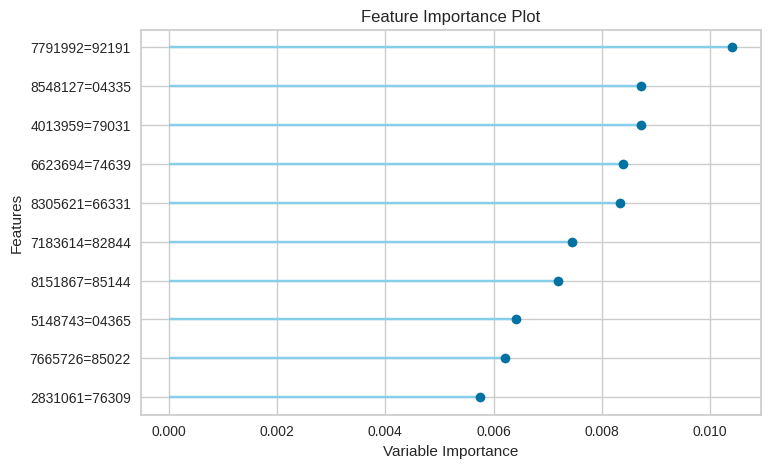

In [ ]:
# Plotando apenas os TOP 10 biomarcadoers mais importantes
classification.plot_model(modelo_lr, plot ="feature")

In [ ]:
# Passo 10: Conclusoes sobre o modelo
# Diversos Modelos de machine learning foram construidos para a predição do diagnóstico de COVID-19 usando dados de LC-MS de pacientes COVID-19
# O modelo de regressão logística foi o que apresentou melhor desempenho preditivo
#  Os top 5 biomarcadores mais importantes para o diagnóstico de COVID-19 foram:L-Phenyl-Alanine, D-fructose, L-Thyrosine, D-manose e L-Thriptofano
# O próximo passo é desenvoler o App para que o modelo seja utilizado nas Unidados de saúde com vista a otimizar a prioridade nos atendimento e da gestão leitos hospitalares.

In [ ]:
# create a custom function
def calculate_specificity(y, y_pred):

    tp, tn, fn, fp = 0.0,0.0,0.0,0.0
    for l,m in enumerate(y):
        if m==y_pred[l] and m==1:
            tp+=1
        if m==y_pred[l] and m==0:
            tn+=1
        if m!=y_pred[l] and m==1:
            fn+=1
        if m!=y_pred[l] and m==0:
            fp+=1

    return tn/(tn+fp)

# add metric to PyCaret
add_metric('specificity', 'specificity', calculate_specificity)

lr = create_model('lr')

In [ ]:
# Passo 11: Salvando o modelo para realizar predições na vida real (Deploy)
classification.save_model(modelo_lr, "melhor_modelo_LR")

INFO:logs:Initializing save_model()
INFO:logs:save_model(model=LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=4680, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False), model_name=melhor_modelo_LR, prep_pipe_=Pipeline(memory=None,
         steps=[('dtypes',
                 DataTypes_Auto_infer(categorical_features=[],
                                      display_types=True, features_todrop=[],
                                      id_columns=[],
                                      ml_usecase='classification',
                                      numerical_features=[], target='Sample',
                                      time_features=[])),
                ('imputer',
                 Simple_Imputer(categorical_strategy='not_available',
                         

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=None,
          steps=[('dtypes',
                  DataTypes_Auto_infer(categorical_features=[],
                                       display_types=True, features_todrop=[],
                                       id_columns=[],
                                       ml_usecase='classification',
                                       numerical_features=[], target='Sample',
                                       time_features=[])),
                 ('imputer',
                  Simple_Imputer(categorical_strategy='not_available',
                                 fill_value_categorical=None,
                                 fill_value_numerical=None,
                                 numeric_strat...
                 ('feature_select', 'passthrough'), ('fix_multi', 'passthrough'),
                 ('dfs', 'passthrough'), ('pca', 'passthrough'),
                 ['trained_model',
                  LogisticRegression(C=1.0, class_weight=None, dual=False,
                 